# Bucket Catalog Visualisation

This notebook turns the raw bucket catalog into a compact visual summary.

What you will learn:
- how to build a tidy catalog DataFrame from bucket filenames
- how to summarize the catalog by mode and day
- how to create a quick visual health-check of the available products
- how to compare the same random patch across the four Maya4 processing levels


## Step 1: Build a Tidy Catalog Table

The filenames already contain enough information to create a useful analytics table.

We convert each filename into structured fields so later grouping operations stay simple and readable.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from maya4 import DEFAULT_BUCKET_ID, list_base_files_in_bucket, parse_product_filename

rows = []
for file_name in sorted(list_base_files_in_bucket(DEFAULT_BUCKET_ID, relative_path=True)):
    if not file_name.endswith('.zarr'):
        continue
    meta = parse_product_filename(file_name)
    rows.append(
        {
            'filename': file_name,
            'acquisition_date': meta['acquisition_date'],
            'acquisition_day': meta['acquisition_date'].date(),
            'satellite': meta['satellite'].upper(),
            'stripmap_mode': meta['stripmap_mode'],
            'polarization': meta['polarization'].upper(),
        }
    )

catalog = pd.DataFrame(rows).sort_values('acquisition_date').reset_index(drop=True)
print('catalog rows:', len(catalog))
print(catalog.head(12).to_string(index=False))


catalog rows: 32
                                                          filename    acquisition_date acquisition_day satellite  stripmap_mode polarization
s1c-s1-raw-s-vv-20250328t052810-20250328t052835-001637-002a0d.zarr 2025-03-28 05:28:10      2025-03-28       S1C              1           VV
s1c-s4-raw-s-vv-20250328t145502-20250328t145535-001643-002a6d.zarr 2025-03-28 14:55:02      2025-03-28       S1C              4           VV
s1c-s4-raw-s-vv-20250328t145527-20250328t145555-001643-002a6d.zarr 2025-03-28 14:55:27      2025-03-28       S1C              4           VV
s1c-s4-raw-s-vv-20250329t061359-20250329t061431-001652-002b01.zarr 2025-03-29 06:13:59      2025-03-29       S1C              4           VV
s1c-s4-raw-s-vv-20250329t061424-20250329t061459-001652-002b01.zarr 2025-03-29 06:14:24      2025-03-29       S1C              4           VV
s1c-s4-raw-s-vv-20250330t051150-20250330t051214-001666-002bd3.zarr 2025-03-30 05:11:50      2025-03-30       S1C              4          

## Step 2: Compute a Few Human-Readable Summaries

A notebook becomes much easier to interpret when it prints a short table before plotting.

Here we compute:
- products per stripmap mode
- products per acquisition day
- the `(mode, polarization)` combinations that exist in the bucket


In [2]:
mode_counts = catalog.groupby('stripmap_mode').size().rename('products')
day_counts = catalog.groupby('acquisition_day').size().rename('products')
mode_pol_counts = catalog.groupby(['stripmap_mode', 'polarization']).size().rename('products')

print('Products per stripmap mode:')
print(mode_counts.to_string())
print()
print('Products per acquisition day:')
print(day_counts.to_string())
print()
print('Products per (mode, polarization):')
print(mode_pol_counts.to_string())


Products per stripmap mode:
stripmap_mode
1     4
2     6
3     1
4    10
5     5
6     6

Products per acquisition day:
acquisition_day
2025-03-28    3
2025-03-29    2
2025-03-30    1
2025-03-31    1
2025-04-01    1
2025-04-03    1
2025-04-05    4
2025-04-06    1
2025-04-07    1
2025-04-14    1
2025-04-16    1
2025-04-17    4
2025-04-20    1
2025-04-21    2
2025-04-22    4
2025-04-24    1
2025-04-26    1
2025-04-27    1
2025-04-29    1

Products per (mode, polarization):
stripmap_mode  polarization
1              VV               4
2              VV               6
3              VV               1
4              VV              10
5              VV               5
6              VV               6


## Step 3: Plot the Catalog Shape

The left chart answers *which stripmap modes dominate the bucket?*

The right chart answers *when were these products acquired?*

Together they give a quick sanity check before you start training or building filters.


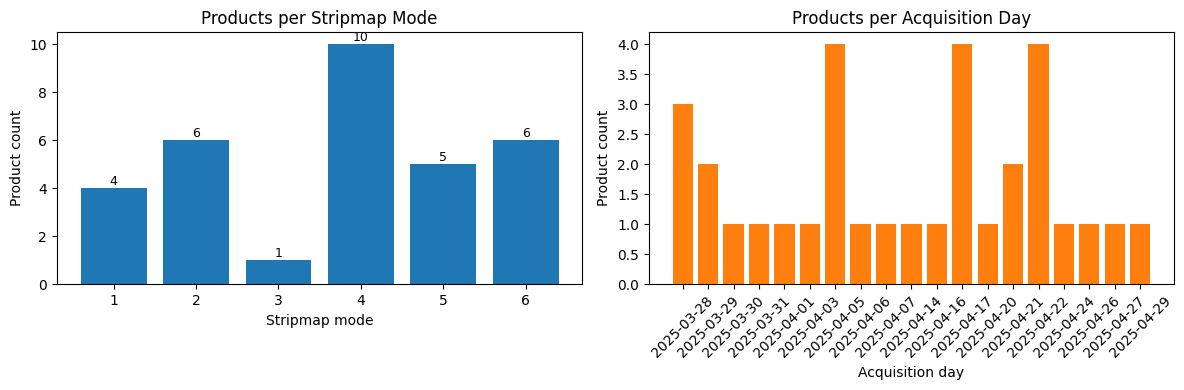

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(mode_counts.index.astype(str), mode_counts.values, color='#1f77b4')
axes[0].set_title('Products per Stripmap Mode')
axes[0].set_xlabel('Stripmap mode')
axes[0].set_ylabel('Product count')
for x, y in zip(mode_counts.index.astype(str), mode_counts.values):
    axes[0].text(x, y, str(int(y)), ha='center', va='bottom', fontsize=9)

axes[1].bar(day_counts.index.astype(str), day_counts.values, color='#ff7f0e')
axes[1].set_title('Products per Acquisition Day')
axes[1].set_xlabel('Acquisition day')
axes[1].set_ylabel('Product count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Step 4: Expand to a Much Larger Patch Around the Same Informative Region

The previous iteration already found a patch whose `az` view contains visible structure, but the context was still too small.

This iteration keeps the same deterministic region and expands around it:
- we reproduce the earlier seeded 512x512 selection
- we use its center as an anchor point
- we expand that window to a **2048x2048** patch, aligned to chunk boundaries
- we download every chunk touched by that larger window for all four levels

This gives much more spatial context while staying reproducible.


In [4]:
import contextlib
import io
import numpy as np
import zarr
from maya4 import download_metadata_from_product, fetch_chunk_from_bucket_zarr

LEVELS = ['raw', 'rc', 'rcmc', 'az']
BASE_PATCH_SIZE = 512
PATCH_SIZE = 2048
RNG_SEED = 7
rng = np.random.default_rng(RNG_SEED)

DATA_DIR = REPO_ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)

selected_row = catalog.sample(n=1, random_state=RNG_SEED).iloc[0]
selected_product = selected_row['filename']

_ = download_metadata_from_product(
    zfile_name=selected_product,
    local_dir=DATA_DIR,
    bucket_id=DEFAULT_BUCKET_ID,
    levels=LEVELS,
    show_progress=False,
)

raw_array = zarr.open(DATA_DIR / selected_product / 'raw', mode='r')
shape = raw_array.shape
chunks = raw_array.chunks

# Reproduce the earlier deterministic 512x512 choice, then expand around its center.
max_chunk_y_base = (shape[0] - BASE_PATCH_SIZE) // chunks[0]
max_chunk_x_base = (shape[1] - BASE_PATCH_SIZE) // chunks[1]
base_chunk_y = int(rng.integers(0, max_chunk_y_base + 1))
base_chunk_x = int(rng.integers(0, max_chunk_x_base + 1))
base_y0 = base_chunk_y * chunks[0]
base_x0 = base_chunk_x * chunks[1]
center_y = base_y0 + BASE_PATCH_SIZE // 2
center_x = base_x0 + BASE_PATCH_SIZE // 2

max_y0 = ((shape[0] - PATCH_SIZE) // chunks[0]) * chunks[0]
max_x0 = ((shape[1] - PATCH_SIZE) // chunks[1]) * chunks[1]
y0 = max(0, min((center_y - PATCH_SIZE // 2) // chunks[0] * chunks[0], max_y0))
x0 = max(0, min((center_x - PATCH_SIZE // 2) // chunks[1] * chunks[1], max_x0))

def covering_chunk_origins(start: int, size: int, chunk_size: int) -> list[int]:
    stop = start + size
    return list(range(start, stop, chunk_size))

chunk_origins_y = covering_chunk_origins(y0, PATCH_SIZE, chunks[0])
chunk_origins_x = covering_chunk_origins(x0, PATCH_SIZE, chunks[1])

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    for level in LEVELS:
        for chunk_origin_y in chunk_origins_y:
            for chunk_origin_x in chunk_origins_x:
                fetch_chunk_from_bucket_zarr(
                    level=level,
                    y=chunk_origin_y,
                    x=chunk_origin_x,
                    local_dir=DATA_DIR,
                    bucket_id=DEFAULT_BUCKET_ID,
                    zarr_archive=selected_product,
                    show_progress=False,
                )

arrays = {level: zarr.open(DATA_DIR / selected_product / level, mode='r') for level in LEVELS}
random_patches = {
    level: arrays[level][y0:y0 + PATCH_SIZE, x0:x0 + PATCH_SIZE]
    for level in LEVELS
}

patch_stats = []
for level in LEVELS:
    magnitude = np.abs(random_patches[level])
    patch_stats.append(
        {
            'level': level,
            'dtype': str(arrays[level].dtype),
            'patch_shape': random_patches[level].shape,
            'chunks_downloaded': len(chunk_origins_y) * len(chunk_origins_x),
            'abs_min': float(magnitude.min()),
            'abs_mean': float(magnitude.mean()),
            'abs_max': float(magnitude.max()),
        }
    )

patch_stats = pd.DataFrame(patch_stats)
print('seed:', RNG_SEED)
print('selected_product:', selected_product)
print('array_shape:', shape)
print('chunk_shape:', chunks)
print('base_patch_size:', BASE_PATCH_SIZE)
print('expanded_patch_size:', PATCH_SIZE)
print('base_patch_window:', {'y_start': base_y0, 'y_end': base_y0 + BASE_PATCH_SIZE, 'x_start': base_x0, 'x_end': base_x0 + BASE_PATCH_SIZE})
print('expanded_patch_window:', {'y_start': y0, 'y_end': y0 + PATCH_SIZE, 'x_start': x0, 'x_end': x0 + PATCH_SIZE})
print('chunk_grid_used:', {'chunk_rows': len(chunk_origins_y), 'chunk_cols': len(chunk_origins_x)})
print(patch_stats.to_string(index=False))


seed: 7
selected_product: s1c-s4-raw-s-vv-20250328t145527-20250328t145555-001643-002a6d.zarr
array_shape: (46539, 21214)
chunk_shape: (256, 256)
base_patch_size: 512
expanded_patch_size: 2048
base_patch_window: {'y_start': 43520, 'y_end': 44032, 'x_start': 12800, 'x_end': 13312}
expanded_patch_window: {'y_start': 42752, 'y_end': 44800, 'x_start': 12032, 'x_end': 14080}
chunk_grid_used: {'chunk_rows': 8, 'chunk_cols': 8}
level      dtype  patch_shape  chunks_downloaded  abs_min    abs_mean      abs_max
  raw  complex64 (2048, 2048)                 64 2.576891    9.919628    37.455753
   rc complex128 (2048, 2048)                 64 1.323681 6592.890629 31011.950152
 rcmc complex128 (2048, 2048)                 64 4.453524 6593.167281 31105.007371
   az complex128 (2048, 2048)                 64 3.801635 6557.034169 37549.344758


## Step 5: Render a Speckle-Reduced Display of the Four-Level Patch

A very large SAR patch can still look unreadable if we display raw speckle directly.

For visualization only, we therefore use a more feature-oriented rendering:
- convert each complex patch to **power**
- apply **8x8 multilooking** by block-averaging that power
- convert the multilooked result to **dB**
- clip each panel to its own **1st to 99th percentile** range
- render with the **cividis** colormap for clearer mid-tone contrast

This is not meant as a radiometric processing step. It is purely a display choice to make scene structure easier to see.


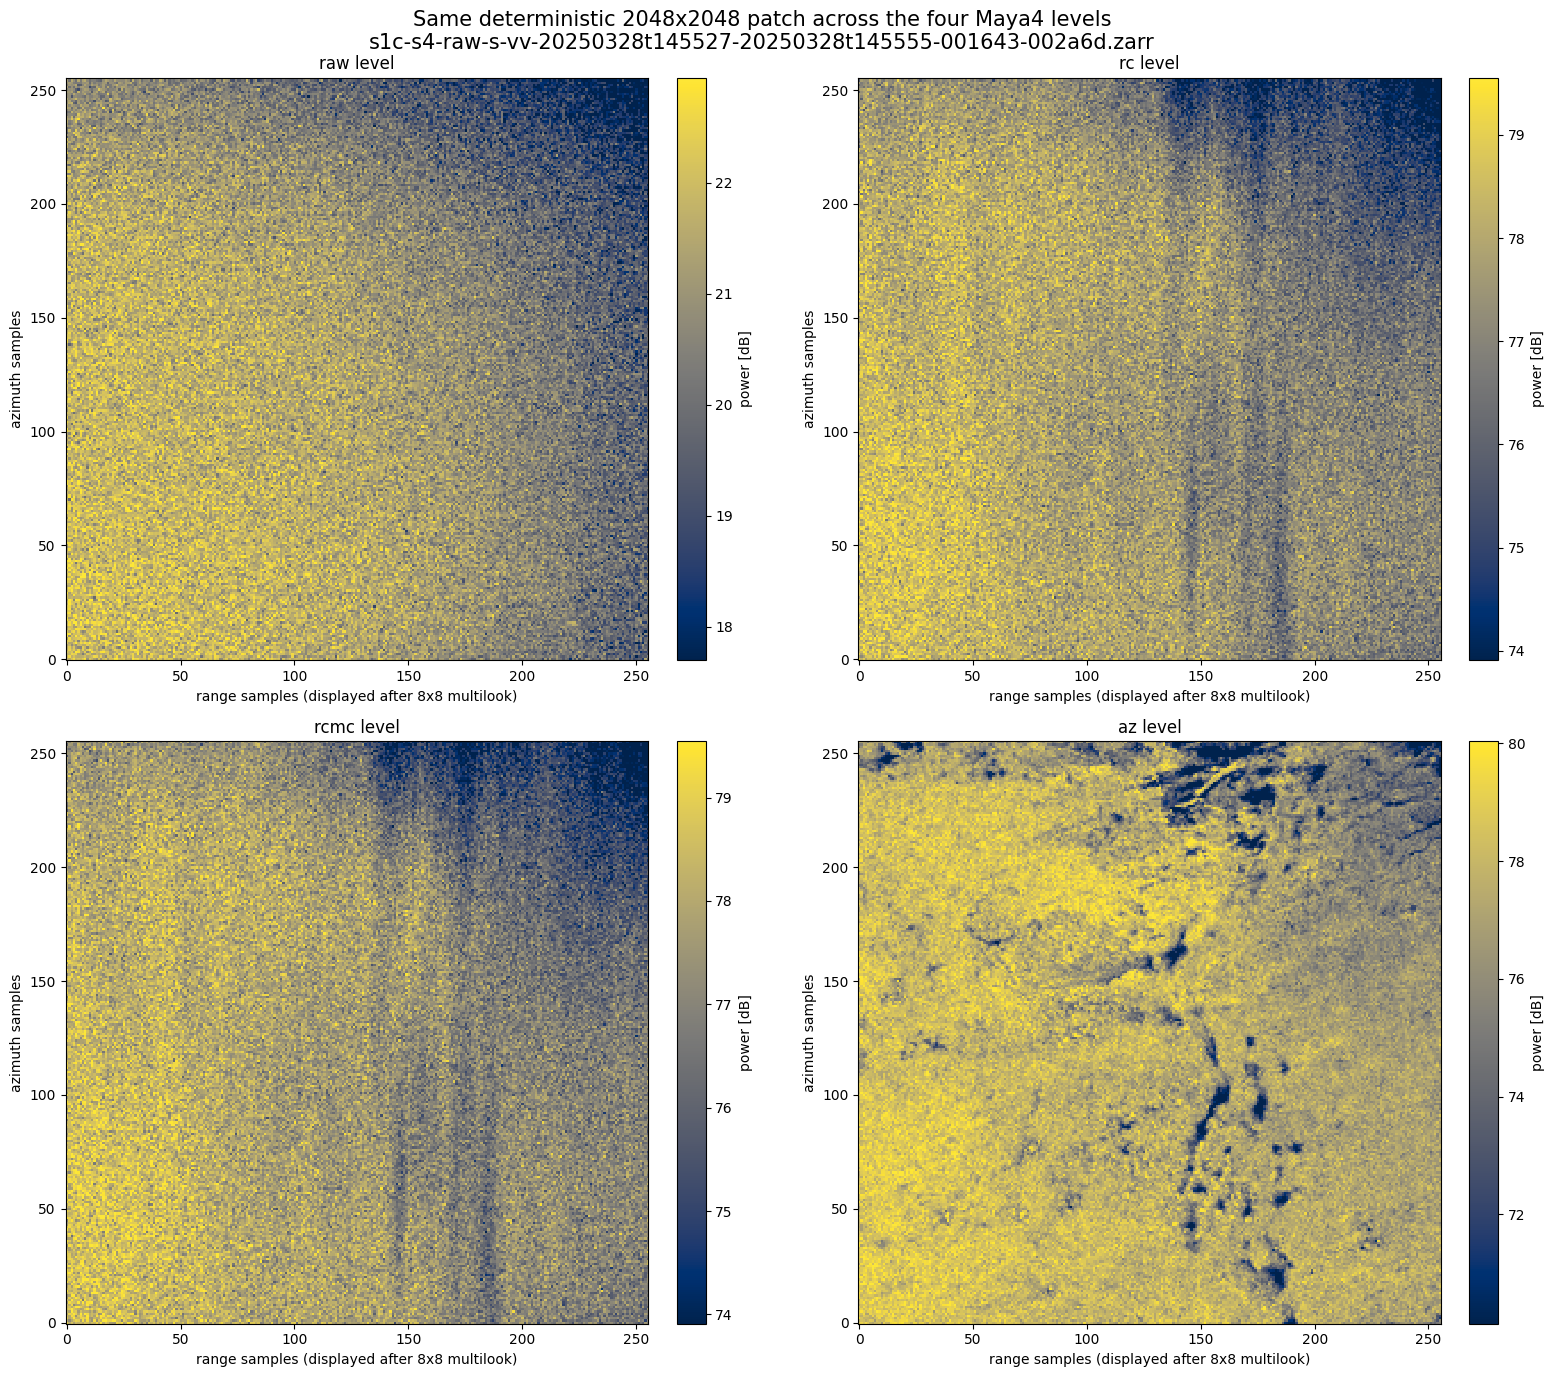

In [ ]:
LOOK_FACTOR = 4

def multilook_power_db(complex_patch, look_factor):
    power = np.abs(complex_patch) ** 2
    h = (power.shape[0] // look_factor) * look_factor
    w = (power.shape[1] // look_factor) * look_factor
    power = power[:h, :w]
    looked = power.reshape(h // look_factor, look_factor, w // look_factor, look_factor).mean(axis=(1, 3))
    return 10.0 * np.log10(np.maximum(looked, 1e-12))

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, level in zip(axes.ravel(), LEVELS):
    image_db = multilook_power_db(random_patches[level], LOOK_FACTOR)
    vmin, vmax = np.percentile(image_db, [1, 99])
    im = ax.imshow(
        image_db,
        cmap='cividis',
        origin='lower',
        vmin=vmin,
        vmax=vmax,
        interpolation='nearest',
    )
    ax.set_title(f'{level} level')
    ax.set_xlabel(f'range samples (displayed after {LOOK_FACTOR}x{LOOK_FACTOR} multilook)')
    ax.set_ylabel('azimuth samples')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='power [dB]')

fig.suptitle(
    'Same deterministic 2048x2048 patch across the four Maya4 levels\n' + selected_product,
    fontsize=15,
)
plt.tight_layout()
plt.show()


## Takeaways

This notebook is useful whenever you want a quick catalog briefing:
- if one mode dominates, your filters may need balancing
- if acquisitions cluster on a few days, temporal splits need extra care
- if a `(mode, polarization)` pair is missing, that is a data constraint, not a loader bug
- the four processing levels can be inspected on the exact same local patch
- a much larger 2048x2048 patch gives the scene enough context to expose larger structures
- multilooked power-in-dB rendering makes those structures easier to see than raw speckled amplitude views
- bucket access stays bounded to the chunks touched by the chosen patch
